---

# Hard vs. Soft Clustering

**Hard clustering** (*like K-means*) assumes that each data point lies in **exactly one** cluster.

On the other hand, **soft clustering** assigns each datapoint a degree of membership for every cluster. This implies that a sample can be in multiple clusters.

When might soft cluster assignments be useful?
- points lying between clusters
- overlapping clusters
- outliers

Soft membership values can be **probabilistic** or not.
- **Probabilistic Constraints**
    1. Sum-to-one - for a single sample, membership values should sum to one across clusters
    2. Non-negative - membership values must be greater than or equal to 0

---

# Fuzzy C-Means (FCM)

**Fuzzy C-Means (FCM)** uses probabilisic, soft cluster memberships.

Objective function:
\begin{align*}
J(\Theta, \mathbf{U}) &= \sum\limits_{n=1}^N\sum\limits_{k=1}^K u_{nk}^m d^2(\mathbf{x}_n, \theta_k)\\
\text{s.t. } & 0 \leq u_{nk}\leq 1\text{ and }\sum\limits_{k=1}^K u_{nk}=1,
\end{align*}
where $\mathbf{x}_n\in \mathbb{R}^D$ is the feature vector for the n-th sample, $\theta_k \in \mathbb{R}^D$ is the mean of cluster $k$, $u_{nk}\in \{u_{ij} \in \mathbb{R} | 0 \leq u_{ij} \leq 1\}$ is the soft assignment, and $m>1$ controls the softness of the memberships (fuzzifier).

Typically, $d^2(\mathbf{x}_n, \theta_k) = \|\mathbf{x}_n - \theta_k\|_2^2$.

---

## Solving for the update equations

### Cluster centroids

Similarly to K-Means, our cluster centroids are randomly initialized for the first iteration.

\begin{align*}
\frac{\partial J}{\partial\theta_k} &= \sum\limits_{n=1}^N -2u_{nk}^m(\mathbf{x_n}-\theta_k)\\
0 &= \sum\limits_{n=1}^N (-2u_{nk}^m \mathbf{x_n} + 2u_{nk}^m\theta_k)\\
& \sum\limits_{n=1}^N u_{nk}^m \mathbf{x_n} = \theta_k\sum\limits_{n=1}^Nu_{nk}^m\\
\theta_k &= \frac{\sum\limits_{n=1}^N u_{nk}^m \mathbf{x_n}}{\sum\limits_{n=1}^N u_{nk}^m}
\end{align*}

### Membership Values

In order to solve for the membership values, we need to enforce the **sum-to-one constraint**, i.e. $\sum\limits_{k=1}^K u_{nk} = 1$.

How do we do that? Form the Lagrangian equivalent to the objective function:

$$\mathcal{L}(\Theta, \mathbf{U}, \Lambda) = \sum\limits_{n=1}^N\sum\limits_{k=1}^K u_{nk}^m\left\| \mathbf{x}_n - \theta_k \right\|^2_2 + \sum\limits_{n=1}^N\lambda_n\left(1 - \sum\limits_{k=1}^K u_{nk}\right),$$
with Lagrange multipliers $\lambda_n \forall n$.

\begin{align*}
\frac{\partial \mathcal{L}}{\partial u_{nk}} &= mu_{nk}^{m-1}\left\| \mathbf{x_n} - \theta_k \right\|^2_2 - \lambda_n = 0\\
u_{nk} &= \left( \frac{\lambda_n}{m\left\| \mathbf{x_n} - \theta_k \right\|^2_2} \right)^{\frac{1}{m-1}}\\
\end{align*}

Since $\sum\limits_{j=1}^K u_{nj} = 1$, we find:

\begin{align*}
\sum\limits_{j=1}^K u_{nj} &= \sum\limits_{j=1}^K \left( \frac{\lambda_n}{m\left\| \mathbf{x_n} - \theta_k \right\|^2_2} \right)^{\frac{1}{m-1}}\\
1 &= \sum\limits_{j=1}^K\left( \frac{\lambda_n^{\frac{1}{m-1}}}{\left(m\left\| \mathbf{x_n} - \theta_j \right\|^2_2\right)^{\frac{1}{m-1}}}\right)\\
1 &= \lambda_n ^{\frac{1}{m-1}} \sum\limits_{j=1}^K \left( \frac{1}{\left(m\left\| \mathbf{x_n} - \theta_j \right\|^2_2\right)^{\frac{1}{m-1}}} \right)\\
\lambda_n^{\frac{1}{m-1}} &= \left(\sum\limits_{j=1}^K \left( \frac{1}{\left(m\left\| \mathbf{x_n} - \theta_j \right\|^2_2\right)^{\frac{1}{m-1}}} \right) \right)^{-1}\\
\end{align*}
Now recall, 
\begin{align*}
u_{nk} &= \left( \frac{\lambda_n}{m\left\| \mathbf{x_n} - \theta_k \right\|^2_2} \right)^{\frac{1}{m-1}}
\end{align*}
Thus,
\begin{align*}
u_{nk} &= \left(\sum\limits_{j=1}^K \left(\frac{1}{\left(m\left\| \mathbf{x_n} - \theta_j \right\|^2_2\right)^{\frac{1}{m-1}}}\right) \right)^{-1} \left(\frac{1}{m\left\| \mathbf{x_n} - \theta_k \right\|^2_2}\right)^{\frac{1}{m-1}}\\
u_{nk} &= \frac{1}{\sum\limits_{j=1}^K\frac{1}{\left(m\left\| \mathbf{x_n} - \theta_j \right\|^2_2\right)^{\frac{1}{m-1}}}}\left(\frac{1}{m\left\| \mathbf{x_n} - \theta_k \right\|^2_2}\right)^{\frac{1}{m-1}}\\
u_{nk} &= \frac{1}{\sum\limits_{j=1}^K \left(\frac{\left\| \mathbf{x_n} - \theta_k \right\|^2_2}{\left\| \mathbf{x_n} - \theta_j \right\|^2_2}\right)^{\frac{1}{m-1}}}
\end{align*}

---

## Pseudo-code

---
**Algorithm 1:** Fuzzy C-Means Algorithm

1. Set number of clusters, \(M\), and fuzzifier \(m\)  
2. Initialize cluster centers  
3. **repeat**  
4. &nbsp;&nbsp;&nbsp;&nbsp;**for** $n = 1 \ \text{to} \ N$ **do**  
5. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**for** $k = 1 \ \text{to} \ K$ **do**  
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**if** $d(\mathbf{x}_n, \theta_k) \neq 0$ **then**  
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $
u_{nk} \leftarrow \frac{1}{\sum\limits_{j=1}^K \left( \frac{d^2(\mathbf{x}_n, \theta_k)}{d^2(\mathbf{x}_n, \theta_j)} \right)^{\frac{1}{m-1}} }
$
8. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**else**  
9. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $u_{nk} = 1$
10. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**end if**  
11. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**end for**  
12. &nbsp;&nbsp;&nbsp;&nbsp;**end for**  
13. &nbsp;&nbsp;&nbsp;&nbsp;**for** $k = 1 \ \text{to} \ K$ **do**  
14. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\theta_k \leftarrow \frac{\sum\limits_{n=1}^N u_{nk}^m \mathbf{x_n}}{\sum\limits_{n=1}^N u_{nk}^m}$
15. &nbsp;&nbsp;&nbsp;&nbsp;**end for**  
16. **until** change in cluster centroids is small
---

---

## Discussion

1. **What constraints are there on the value of the fuzzifier $m$? Why?**

<div style="margin-left: 40px;">

The fuzzifier is a positive scalar ($m>0$). In particular, the fuzzier is constrained to be $m>1$. This is a direct constraint from the update equation of the membership values $u_{nk}$.
</div>

2. **How do results change as $m$ approaches 1? 2? 3? How do results change with changes in $m$? Can $m$ get too big? too small?**

<div style="margin-left: 40px;">

When $m\rightarrow 1$, FCM approaches the K-Means solution. The membership values for each data point start to be become "hard" as in K-Means.

As the fuzzifier $m$ increases ($m\rightarrow \infty$), data points far away from the cluster center become fuzzy, "less unsure" about cluster membership.

For data points closest to the cluster centers are the point more "certain" about their membership in each cluster. The data points further apart from the cluster centers, become fuzzier and their memberships become more "uncertain". Then, effectively, the value for the fuzzifier $m$ can get too small or too large.
</div>

3. **Does FCM find the globally optimal solution? Why or why not? What sort of optimization strategy is being used in the FCM algorithm?**

<div style="margin-left: 40px;">

FCM uses alternating optimization. The alternating optimization makes it sensible to cluster centers initialization, therefore not reaching the global optimal solution.
</div>

4. **What FCM membership values would a point that is located exactly halfway between two clusters centers (when clustering into two clusters) obtain?**

<div style="margin-left: 40px;">

For a point that is exactly halfway between two clusters (when clustering into two clusters) would have a membership value of 0.5 because their cluster assignment is purely based on the distance to the cluster center. This means that that particular data point is being equally shared by the two clusters.
</div>

5. **What FCM membership values an outlier data point receive? An outlier data point would be one that is far from all cluster representatives.**

<div style="margin-left: 40px;">

An outlier can receive a membership value close to 0 for all clusters. This is because the membership values in FCM represent the degree of belongingness of a data point to each cluster. An outlier data point that is far from all cluster representatives will have low membership values for all clusters, indicating that it does not belong strongly to any of them.

However, the exact membership values assigned to an outlier data point depend on the fuzziness parameter $m$ and the distance between the data point and the cluster centers. A smaller value of $m$ would result in lower membership values for the outlier data point, while a larger value of $m$ would allow the data point to have higher membership values for the clusters even if it is far away from their centers.
</div>

6. **What may be some advantages of FCM over K-Means? disadvantages?**
<div style="margin-left: 40px;">

FCM works best for a scenario where data contains natural overlapping clusters. As opposed to assign a hard membership like in K-Means, FCM returns soft memberships for points where the two clusters intercept/overlap.
</div>

---

# Possibilistic C-Means

**Possibilistic C-means (PCM)** removes the sum-to-one constraint on membership values.

Why is removing this constraint beneficial?
- It allows outliers to have negligible membership in every cluster. Thus, PCM handles outliers better than FCM.

Possibilistic C-means objective function:

\begin{align*}
J(\Theta, \mathbf{U}, \mathbf{H}) &= \sum_{n=1}^N \sum_{k=1}^K u_{nk}^m d^2(\mathbf{x}_n, \theta_k) + \sum_{k=1}^K \eta_k \sum_{n=1}^N (1 - u_{nk})^m
\end{align*}

where $\mathbf{x}_n\in \mathbb{R}^D$ is the feature vector for the n-th sample, $\theta_k \in \mathbb{R}^D$ is the mean of cluster $k$, $u_{nk}\in \{u_{ij} \in \mathbb{R} | 0 \leq u_{ij} \leq 1 \text{ and } 0 \leq \sum\limits_{i=1}^N u_{ij} \leq N\}$ is the soft assignment, $m>1$ controls the softness of the memberships (fuzzifier), and $\eta_k>0$ is a scaling parameter.

Since there is not sum-to-one constraint in PCM, memberships would be encouraged to shrink to 0 without the second term. Thus, the second term ensures that memberships do not get pushed to a trivial solution.

The update equation for the **membership values** is:

\begin{align*}
u_{nk} = \frac{1}{1+\left(\frac{d^2(\mathbf{x}_n,\theta_k)}{\eta_k}\right)^{\frac{1}{m-1}}}
\end{align*}

Notice, 

\begin{align*}
\lim_{d^2 \to \infty} u_{nk} 
&= \lim_{d^2 \to \infty} \frac{1}{1 + \left(\tfrac{d^2}{\eta_k}\right)^{\tfrac{1}{m-1}}}. \\
\lim_{d^2 \to \infty} u_{nk} &= \frac{1}{1 + \left(\tfrac{\infty}{\eta_k}\right)^{\tfrac{1}{m-1}}} = 0
\end{align*}

and 

\begin{align*}
\lim_{d^2 \to 0} u_{nk} 
= \frac{1}{1 + 0} = 1
\end{align*}

From this, we can also see how $eta_k$ controls the "tightness" of the cluster by scaling the distance of points to the centroid.

The update for the **cluster representatives** is defined as:

$$\theta_k = \frac{\sum\limits_{n=1}^N u^m_{nk}\mathbf{x}_n}{\sum\limits_{n=1}^N u^m_{nk}}$$

---

## Discussions

1. **What constraints are there on the value of the fuzzifier $m$? Why?**

<div style="margin-left: 40px;">

The fuzzifier is a positive scalar ($m>0$). In particular, the fuzzifier is constrained to be $m>1$. This is a direct constraint from the update equation of the membership values $u_{ij}$.
</div>

2. **What constraints are there on the values of the weights $\eta_j$?**

<div style="margin-left: 40px;">

The value of the weight parameter for each cluster $\eta_j$ is $\eta_j>0 \; \forall j$.
</div>

3. **Does PCM find the globally optimal solution? Why or why not? What sort of optimization strategy is being used in the PCM algorithm?**

<div style="margin-left: 40px;">

PCM uses alternating optimization. The alternating optimization makes it sensible to cluster centers initialization, therefore not reaching the global optimal solution.
</div>

4. **How do results change as $m$ changes?**

<div style="margin-left: 40px;">

Just like FCM, when $m\rightarrow 1$, PCM approaches the K-Means solution. As the fuzzifier $m$ increases ($m\rightarrow \infty$), data points far away from the cluster center become fuzzy, "less sure" about cluster membership.
</div>

---

# Comparison of FCM and PCM in Handling Outliers

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

plt.rcParams['font.size'] = 14
sns.set_style("whitegrid")

sns.set_context("notebook", font_scale=1.5)
np.random.seed(42)

class FCM:
    """Fuzzy C-Means Clustering"""
    def __init__(self, n_clusters=3, m=2.0, max_iter=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.m = m  # Fuzziness parameter
        self.max_iter = max_iter
        self.tol = tol
        
    def fit(self, X):
        n_samples, n_features = X.shape
        
        # Initialize membership matrix randomly
        self.u = np.random.rand(n_samples, self.n_clusters)
        # Normalize so each row sums to 1
        self.u = self.u / self.u.sum(axis=1, keepdims=True)
        
        self.centers = np.zeros((self.n_clusters, n_features))
        
        for iteration in range(self.max_iter):
            # Update cluster centers
            u_m = self.u ** self.m
            self.centers = (u_m.T @ X) / u_m.sum(axis=0, keepdims=True).T
            
            # Update membership matrix
            distances = euclidean_distances(X, self.centers)
            
            # Avoid division by zero
            distances = np.fmax(distances, np.finfo(np.float64).eps)
            
            new_u = np.zeros_like(self.u)
            for i in range(n_samples):
                for j in range(self.n_clusters):
                    denominator = sum((distances[i, j] / distances[i, k]) ** (2/(self.m-1)) 
                                    for k in range(self.n_clusters))
                    new_u[i, j] = 1.0 / denominator
            
            # Check convergence
            if np.linalg.norm(new_u - self.u) < self.tol:
                break
                
            self.u = new_u
            
        return self
    
    def predict(self):
        return np.argmax(self.u, axis=1)

class PCM:
    """Possibilistic C-Means Clustering"""
    def __init__(self, n_clusters=3, m=2.0, max_iter=100, tol=1e-4, eta_factor=1.0):
        self.n_clusters = n_clusters
        self.m = m  # Fuzziness parameter
        self.max_iter = max_iter
        self.tol = tol
        self.eta_factor = eta_factor
        
    def fit(self, X):
        n_samples, n_features = X.shape
        
        # Initialize with FCM to get good starting points
        fcm = FCM(self.n_clusters, self.m, max_iter=20)
        fcm.fit(X)
        
        self.u = fcm.u.copy()
        self.centers = fcm.centers.copy()
        
        # Calculate eta parameters based on FCM results
        distances = euclidean_distances(X, self.centers)
        self.eta = np.zeros(self.n_clusters)
        
        for j in range(self.n_clusters):
            u_m = self.u[:, j] ** self.m
            numerator = np.sum(u_m * (distances[:, j] ** 2))
            denominator = np.sum(u_m)
            self.eta[j] = self.eta_factor * (numerator / denominator) if denominator > 0 else 1.0
        
        # PCM iterations
        for iteration in range(self.max_iter):
            # Update cluster centers
            u_m = self.u ** self.m
            for j in range(self.n_clusters):
                if u_m[:, j].sum() > 0:
                    self.centers[j] = (u_m[:, j][:, np.newaxis] * X).sum(axis=0) / u_m[:, j].sum()
            
            # Update membership matrix (PCM style - no constraint that rows sum to 1)
            distances = euclidean_distances(X, self.centers)
            distances = np.fmax(distances, np.finfo(np.float64).eps)
            
            new_u = np.zeros_like(self.u)
            for i in range(n_samples):
                for j in range(self.n_clusters):
                    if distances[i, j] > 0 and self.eta[j] > 0:
                        new_u[i, j] = 1.0 / (1.0 + ((distances[i, j] ** 2) / self.eta[j]) ** (1/(self.m-1)))
                    else:
                        new_u[i, j] = 1.0
            
            # Check convergence
            if np.linalg.norm(new_u - self.u) < self.tol:
                break
                
            self.u = new_u
            
        return self
    
    def predict(self):
        return np.argmax(self.u, axis=1)

def generate_data_with_outliers():
    """Generate clustered data with clear outliers"""
    # Generate 3 well-separated clusters
    cluster1 = np.random.multivariate_normal([2, 2], [[0.5, 0], [0, 0.5]], 100)
    cluster2 = np.random.multivariate_normal([8, 2], [[0.5, 0], [0, 0.5]], 100)
    cluster3 = np.random.multivariate_normal([5, 8], [[0.5, 0], [0, 0.5]], 100)
    
    # Add clear outliers
    outliers = np.array([
        [0, 8],    # Far from any cluster
        [10, 0],   # Far from any cluster
        [10, 10],  # Far from any cluster
        [0, 0],    # Far from any cluster
        [-1, 5],   # Far from any cluster
        [6, 0],    # Between clusters 1 and 2
        [11, 6],   # Far from any cluster
    ])
    
    # Combine data
    clean_data = np.vstack([cluster1, cluster2, cluster3])
    all_data = np.vstack([clean_data, outliers])
    
    # Labels (outliers get label -1)
    clean_labels = np.hstack([np.zeros(100), np.ones(100), np.full(100, 2)])
    outlier_labels = np.full(len(outliers), -1)
    all_labels = np.hstack([clean_labels, outlier_labels])
    
    return all_data, all_labels, len(outliers)

def plot_membership_comparison(data, fcm_model, pcm_model, outlier_indices, title):
    """Plot FCM vs PCM membership values"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    n_outliers = len(outlier_indices)
    clean_data = data[:-n_outliers]
    outlier_data = data[-n_outliers:]
    
    # FCM memberships
    fcm_u = fcm_model.u
    fcm_clean = fcm_u[:-n_outliers]
    fcm_outliers = fcm_u[-n_outliers:]
    
    # PCM memberships  
    pcm_u = pcm_model.u
    pcm_clean = pcm_u[:-n_outliers]
    pcm_outliers = pcm_u[-n_outliers:]
    
    colors = ['red', 'blue', 'green']
    
    for cluster in range(3):
        # FCM membership for this cluster
        axes[0, cluster].scatter(clean_data[:, 0], clean_data[:, 1], 
                                c=fcm_clean[:, cluster], cmap='Reds', 
                                alpha=0.7, s=30, vmin=0, vmax=1)
        # Highlight outliers
        scatter = axes[0, cluster].scatter(outlier_data[:, 0], outlier_data[:, 1], 
                                         c=fcm_outliers[:, cluster], cmap='Reds',
                                         s=200, marker='X', edgecolors='black', 
                                         linewidths=2, vmin=0, vmax=1)
        
        axes[0, cluster].scatter(fcm_model.centers[cluster, 0], fcm_model.centers[cluster, 1],
                               c=colors[cluster], marker='*', s=300, edgecolors='black', linewidths=2)
        axes[0, cluster].set_title(f'FCM: Cluster {cluster} Membership')
        axes[0, cluster].set_xlabel('X')
        axes[0, cluster].set_ylabel('Y')
        axes[0, cluster].grid(True, alpha=0.3)
        
        # Add colorbar
        plt.colorbar(scatter, ax=axes[0, cluster], label='Membership')
        
        # PCM membership for this cluster
        axes[1, cluster].scatter(clean_data[:, 0], clean_data[:, 1], 
                                c=pcm_clean[:, cluster], cmap='Blues', 
                                alpha=0.7, s=30, vmin=0, vmax=1)
        # Highlight outliers
        scatter2 = axes[1, cluster].scatter(outlier_data[:, 0], outlier_data[:, 1], 
                                          c=pcm_outliers[:, cluster], cmap='Blues',
                                          s=200, marker='X', edgecolors='black', 
                                          linewidths=2, vmin=0, vmax=1)
        
        axes[1, cluster].scatter(pcm_model.centers[cluster, 0], pcm_model.centers[cluster, 1],
                               c=colors[cluster], marker='*', s=300, edgecolors='black', linewidths=2)
        axes[1, cluster].set_title(f'PCM: Cluster {cluster} Membership')
        axes[1, cluster].set_xlabel('X')
        axes[1, cluster].set_ylabel('Y')
        axes[1, cluster].grid(True, alpha=0.3)
        
        # Add colorbar
        plt.colorbar(scatter2, ax=axes[1, cluster], label='Membership')
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def analyze_outlier_memberships(fcm_model, pcm_model, n_outliers):
    """Analyze how outliers are handled by FCM vs PCM"""
    print("🔍 OUTLIER ANALYSIS:")
    print("="*60)
    
    fcm_outliers = fcm_model.u[-n_outliers:]
    pcm_outliers = pcm_model.u[-n_outliers:]
    
    print("FCM Outlier Memberships (must sum to 1.0):")
    for i, memberships in enumerate(fcm_outliers):
        total = memberships.sum()
        max_membership = memberships.max()
        print(f"  Outlier {i+1}: {memberships} | Sum: {total:.3f} | Max: {max_membership:.3f}")
    
    print("\nPCM Outlier Memberships (can be low for all clusters):")
    for i, memberships in enumerate(pcm_outliers):
        total = memberships.sum()
        max_membership = memberships.max()
        print(f"  Outlier {i+1}: {memberships} | Sum: {total:.3f} | Max: {max_membership:.3f}")
    
    # Calculate average maximum membership for outliers
    fcm_avg_max = fcm_outliers.max(axis=1).mean()
    pcm_avg_max = pcm_outliers.max(axis=1).mean()
    
    print(f"\nAverage maximum membership for outliers:")
    print(f"• FCM: {fcm_avg_max:.3f} (forced to assign)")
    print(f"• PCM: {pcm_avg_max:.3f} (can reject)")


Dataset: 307 points total, 7 clear outliers
💡 Outliers are marked with X symbols


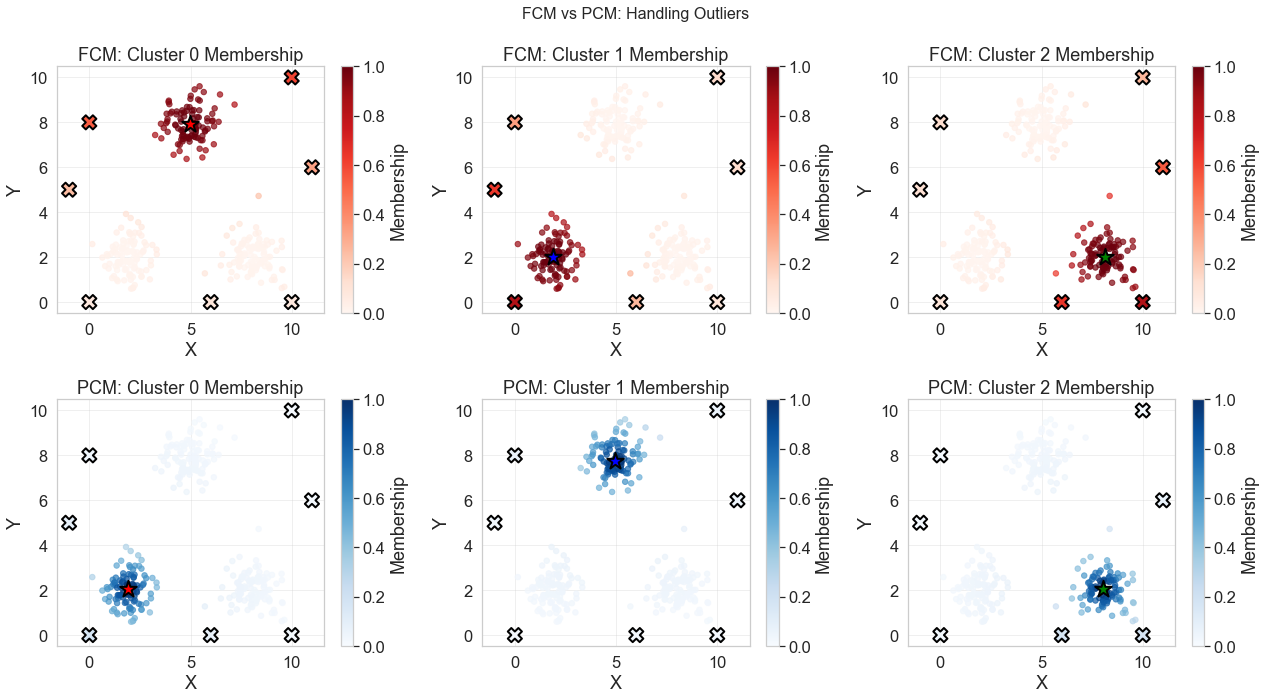

🔍 OUTLIER ANALYSIS:
FCM Outlier Memberships (must sum to 1.0):
  Outlier 1: [0.53397141 0.336024   0.13000459] | Sum: 1.000 | Max: 0.534
  Outlier 2: [0.07249777 0.09115906 0.83634317] | Sum: 1.000 | Max: 0.836
  Outlier 3: [0.59903391 0.13711497 0.26385112] | Sum: 1.000 | Max: 0.599
  Outlier 4: [0.07328814 0.83530387 0.09140799] | Sum: 1.000 | Max: 0.835
  Outlier 5: [0.24753451 0.63371053 0.11875496] | Sum: 1.000 | Max: 0.634
  Outlier 6: [0.08723508 0.26475133 0.64801359] | Sum: 1.000 | Max: 0.648
  Outlier 7: [0.32709562 0.13222616 0.54067822] | Sum: 1.000 | Max: 0.541

PCM Outlier Memberships (can be low for all clusters):
  Outlier 1: [0.04084619 0.07085513 0.01707563] | Sum: 0.129 | Max: 0.071
  Outlier 2: [0.02355838 0.02158135 0.1765019 ] | Sum: 0.222 | Max: 0.177
  Outlier 3: [0.01283893 0.0586078  0.02518019] | Sum: 0.097 | Max: 0.059
  Outlier 4: [0.17561352 0.02173449 0.02466108] | Sum: 0.222 | Max: 0.176
  Outlier 5: [0.08794918 0.04180171 0.01887145] | Sum: 0.149 | Max:

In [13]:
# Generate data with outliers
data, labels, n_outliers = generate_data_with_outliers()

print(f"Dataset: {len(data)} points total, {n_outliers} clear outliers")
print("💡 Outliers are marked with X symbols")

# Fit both models
fcm = FCM(n_clusters=3, m=2.0, max_iter=100)
fcm.fit(data)

pcm = PCM(n_clusters=3, m=2.0, max_iter=100, eta_factor=1.5)
pcm.fit(data)

# Visualize results
outlier_indices = list(range(len(data) - n_outliers, len(data)))
plot_membership_comparison(data, fcm, pcm, outlier_indices, 
                         "FCM vs PCM: Handling Outliers")

# Analyze outlier treatment
analyze_outlier_memberships(fcm, pcm, n_outliers)